# Weekend Cineplex Scheduling Experiments

This notebook runs experiments for a **weekend** scheduling scenario across three dataset sizes:
- **Small**: 6 movies, 2 halls
- **Medium**: 12 movies, 6 halls
- **Large**: 30 movies, 15 halls

**Sections:**
1. Mutation rate tuning on the large dataset
2. Number of generations tuning via convergence analysis with early stopping (patience = 50)
3. ILP vs GA comparison using tuned hyperparameters -- scalability and solution quality vs runtime
4. Schedule Gantt charts -- visual comparison of ILP and GA schedules for all datasets
5. Summary & observations

In [21]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from heuristic_ga.ga_solver import solve_schedule_ga
from exact_method.exact_scheduler import solve_schedule_ilp

DAY_TYPE = "weekend"
SEEDS = [11, 22, 33, 44, 55]

DATASETS = {
    "small": {
        "movies_csv": REPO_ROOT / "common" / "movies_small.csv",
        "config_json": REPO_ROOT / "common" / "small_config.json",
    },
    "medium": {
        "movies_csv": REPO_ROOT / "common" / "movies_medium.csv",
        "config_json": REPO_ROOT / "common" / "med_config.json",
    },
    "large": {
        "movies_csv": REPO_ROOT / "common" / "movies_large.csv",
        "config_json": REPO_ROOT / "common" / "large_config.json",
    },
}

DATASET_NUM_MOVIES = {"small": 6, "medium": 12, "large": 30}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Setup complete.")

Setup complete.


## 1. Mutation Rate Tuning (Large Dataset)

Sweep `mutation_percent_genes` over `[5, 10, 15, 20, 25, 30, 40, 50]` on the **large** dataset (5 seeds each). The ideal rate is the one that yields the highest mean revenue across seeds.

In [22]:
MUTATION_RATES = [5, 10, 15, 20, 25, 30, 40, 50]

tuning_revenues: dict[int, list[float]] = {rate: [] for rate in MUTATION_RATES}

ds = DATASETS["large"]
total_runs = len(MUTATION_RATES) * len(SEEDS)
run_i = 0

for rate in MUTATION_RATES:
    for seed in SEEDS:
        run_i += 1
        print(f"\r[{run_i}/{total_runs}] large | mut={rate}% | seed={seed}", end="", flush=True)
        result = solve_schedule_ga(
            movies_csv=ds["movies_csv"],
            config_json=ds["config_json"],
            day_type=DAY_TYPE,
            seed=seed,
            mutation_percent_genes=float(rate),
        )
        tuning_revenues[rate].append(result["metadata"]["total_revenue"])

print("\nMutation-rate sweep complete.")

[40/40] large | mut=50% | seed=55
Mutation-rate sweep complete.


Ideal mutation_percent_genes = 5%
  Mean revenue = 33,113 +/- 458

  mut= 5%  mean_rev=    33,113  std=     458 <-- best
  mut=10%  mean_rev=    23,852  std=       0
  mut=15%  mean_rev=    23,852  std=       0
  mut=20%  mean_rev=    23,852  std=       0
  mut=25%  mean_rev=    23,852  std=       0
  mut=30%  mean_rev=    23,852  std=       0
  mut=40%  mean_rev=    23,852  std=       0
  mut=50%  mean_rev=    23,852  std=       0


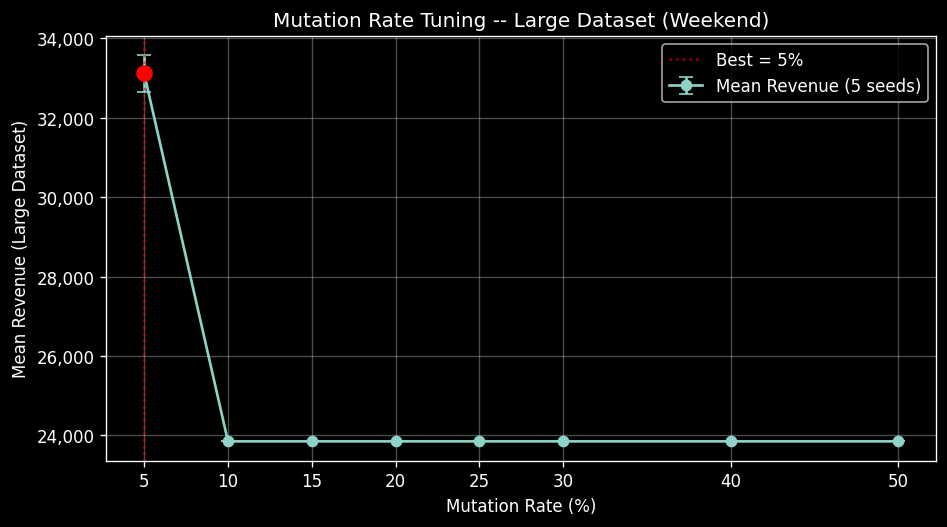

In [23]:
mean_revs = [np.mean(tuning_revenues[rate]) for rate in MUTATION_RATES]
std_revs = [np.std(tuning_revenues[rate]) for rate in MUTATION_RATES]

best_idx = int(np.argmax(mean_revs))
IDEAL_MUTATION_RATE = MUTATION_RATES[best_idx]

print(f"Ideal mutation_percent_genes = {IDEAL_MUTATION_RATE}%")
print(f"  Mean revenue = {mean_revs[best_idx]:,.0f} +/- {std_revs[best_idx]:,.0f}")
print()
for rate, m, s in zip(MUTATION_RATES, mean_revs, std_revs):
    marker = " <-- best" if rate == IDEAL_MUTATION_RATE else ""
    print(f"  mut={rate:>2d}%  mean_rev={m:>10,.0f}  std={s:>8,.0f}{marker}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(MUTATION_RATES, mean_revs, yerr=std_revs, fmt="o-", capsize=4, linewidth=1.6, label="Mean Revenue (5 seeds)")
ax.axvline(IDEAL_MUTATION_RATE, color="red", linestyle=":", alpha=0.6, label=f"Best = {IDEAL_MUTATION_RATE}%")
ax.scatter([IDEAL_MUTATION_RATE], [mean_revs[best_idx]], color="red", zorder=5, s=80)

ax.set_xlabel("Mutation Rate (%)")
ax.set_ylabel("Mean Revenue (Large Dataset)")
ax.set_title("Mutation Rate Tuning -- Large Dataset (Weekend)")
ax.set_xticks(MUTATION_RATES)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

## 2. Number of Generations Tuning (Early Stopping)

Run the GA on the **large** dataset with a high generation ceiling (1000) using the tuned mutation rate. Apply post-hoc early stopping with **patience = 50** (no improvement for 50 consecutive generations) to determine the optimal number of generations.

In [24]:
EXPLORATION_GENS = 1000
CONVERGENCE_SEED = 42

ds = DATASETS["large"]
print(f"Running GA on large dataset ({EXPLORATION_GENS} generations)...", end=" ", flush=True)

convergence_result = solve_schedule_ga(
    movies_csv=ds["movies_csv"],
    config_json=ds["config_json"],
    day_type=DAY_TYPE,
    seed=CONVERGENCE_SEED,
    num_generations=EXPLORATION_GENS,
    mutation_percent_genes=float(IDEAL_MUTATION_RATE),
)

convergence_data = convergence_result["convergence"]
print(f"done  (revenue={convergence_result['metadata']['total_revenue']:,.0f},"
      f" time={convergence_result['metadata']['execution_time_seconds']:.1f}s)")
print(f"  Generations run: {len(convergence_data['best_fitness_history'])}")

Running GA on large dataset (1000 generations)... done  (revenue=36,346, time=22.1s)
  Generations run: 1000


Last fitness improvement at generation 984
Patience = 50
OPTIMAL_NUM_GENERATIONS = 1000
  Best fitness at plateau: 36,346


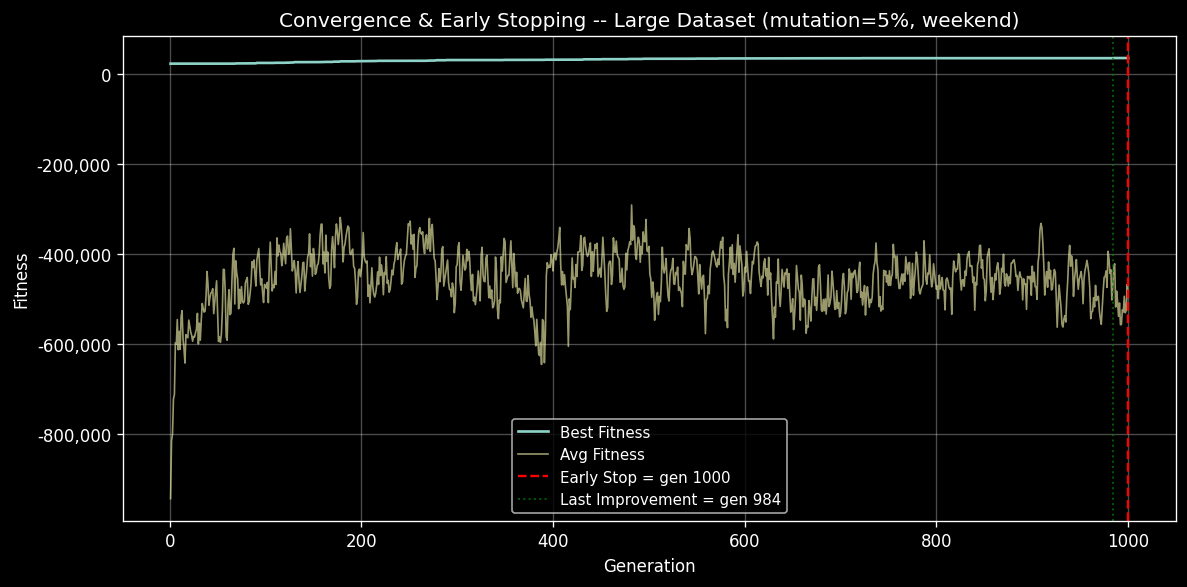

In [25]:
PATIENCE = 50

best_hist = convergence_data["best_fitness_history"]
avg_hist = convergence_data["avg_fitness_history"]

last_improvement = 0
for g in range(1, len(best_hist)):
    if best_hist[g] > best_hist[g - 1]:
        last_improvement = g

OPTIMAL_NUM_GENERATIONS = min(last_improvement + PATIENCE, len(best_hist))

print(f"Last fitness improvement at generation {last_improvement}")
print(f"Patience = {PATIENCE}")
print(f"OPTIMAL_NUM_GENERATIONS = {OPTIMAL_NUM_GENERATIONS}")
print(f"  Best fitness at plateau: {best_hist[last_improvement]:,.0f}")

gens = np.arange(1, len(best_hist) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gens, best_hist, label="Best Fitness", linewidth=1.6)
ax.plot(gens, avg_hist, label="Avg Fitness", linewidth=1.0, alpha=0.6)
ax.axvline(
    OPTIMAL_NUM_GENERATIONS, color="red", linestyle="--", linewidth=1.4,
    label=f"Early Stop = gen {OPTIMAL_NUM_GENERATIONS}",
)
ax.axvline(
    last_improvement, color="green", linestyle=":", linewidth=1.2, alpha=0.7,
    label=f"Last Improvement = gen {last_improvement}",
)

ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.set_title(f"Convergence & Early Stopping -- Large Dataset (mutation={IDEAL_MUTATION_RATE}%, weekend)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3. ILP vs GA -- Scalability & Solution Quality

Run both solvers on every dataset to collect runtime and revenue for side-by-side comparison.

In [26]:
import json

ILP_TIME_LIMITS = {"small": 60, "medium": 180, "large": 600}

ilp_results: dict[str, dict] = {}

for ds_name, ds in DATASETS.items():
    tl = ILP_TIME_LIMITS[ds_name]
    print(f"Running ILP for {ds_name} (time_limit={tl}s)...", end=" ", flush=True)
    result = solve_schedule_ilp(
        movies_csv=ds["movies_csv"],
        config_json=ds["config_json"],
        day_type=DAY_TYPE,
        time_limit_seconds=tl,
    )
    meta = result["metadata"]
    ilp_results[ds_name] = {
        "revenue": meta["total_revenue"],
        "runtime": meta["execution_time_seconds"],
        "status": meta["solver_status"],
        "num_movies": meta["num_movies"],
        "schedule": result["schedule"],
    }

    out_path = REPO_ROOT / "exact_method" / f"schedule_{ds_name}_ilp.json"
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"done  status={meta['solver_status']}  revenue={meta['total_revenue']:,.0f}"
          f"  time={meta['execution_time_seconds']:.1f}s  -> {out_path.name}")

print("\nAll ILP runs complete.")

Running ILP for small (time_limit=60s)... done  status=OPTIMAL  revenue=3,884  time=0.2s  -> schedule_small_ilp.json
Running ILP for medium (time_limit=180s)... done  status=OPTIMAL  revenue=16,527  time=0.4s  -> schedule_medium_ilp.json
Running ILP for large (time_limit=600s)... done  status=FEASIBLE  revenue=46,454  time=610.1s  -> schedule_large_ilp.json

All ILP runs complete.


In [27]:
print(f"Tuned hyperparameters:  mutation={IDEAL_MUTATION_RATE}%  generations={OPTIMAL_NUM_GENERATIONS}")

ga_comparison_results: dict[str, dict] = {}

for ds_name, ds in DATASETS.items():
    print(f"Running GA for {ds_name}...", end=" ", flush=True)
    result = solve_schedule_ga(
        movies_csv=ds["movies_csv"],
        config_json=ds["config_json"],
        day_type=DAY_TYPE,
        seed=42,
        num_generations=OPTIMAL_NUM_GENERATIONS,
        mutation_percent_genes=float(IDEAL_MUTATION_RATE),
    )
    meta = result["metadata"]
    ga_comparison_results[ds_name] = {
        "revenue": meta["total_revenue"],
        "runtime": meta["execution_time_seconds"],
        "num_movies": meta["num_movies"],
        "schedule": result["schedule"],
    }

    out_path = REPO_ROOT / "heuristic_ga" / f"schedule_{ds_name}_ga.json"
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"done  revenue={meta['total_revenue']:,.0f}"
          f"  time={meta['execution_time_seconds']:.1f}s  -> {out_path.name}")

print("\nAll GA comparison runs complete.")

Tuned hyperparameters:  mutation=5%  generations=1000
Running GA for small... done  revenue=3,859  time=7.7s  -> schedule_small_ga.json
Running GA for medium... done  revenue=16,307  time=11.5s  -> schedule_medium_ga.json
Running GA for large... done  revenue=36,346  time=21.9s  -> schedule_large_ga.json

All GA comparison runs complete.


In [35]:
from validator import validate

print("Validating all schedules...")
all_ok = True
for ds_name in ["small", "medium", "large"]:
    ds = DATASETS[ds_name]
    for method, folder in [("ilp", "exact_method"), ("ga", "heuristic_ga")]:
        sched_path = REPO_ROOT / folder / f"schedule_{ds_name}_{method}.json"
        ok, issues = validate(
            sched_path,
            ds["movies_csv"],
            ds["config_json"],
            day_type=DAY_TYPE,
            relax_min_shows=False,
        )
        status = "PASS" if ok else "FAIL"
        print(f"  {ds_name:>6s} {method.upper():<3s}  {status}", end="")
        if not ok:
            all_ok = False
            print(f"  ({len(issues)} issues)")
            for issue in issues[:5]:
                print(f"        - {issue}")
            if len(issues) > 5:
                print(f"        ... and {len(issues) - 5} more")
        else:
            print()

print(f"\n{'All schedules valid.' if all_ok else 'Some schedules have issues -- see above.'}")

Validating all schedules...
   small ILP  PASS
   small GA   PASS
  medium ILP  PASS
  medium GA   PASS
   large ILP  PASS
   large GA   PASS

All schedules valid.


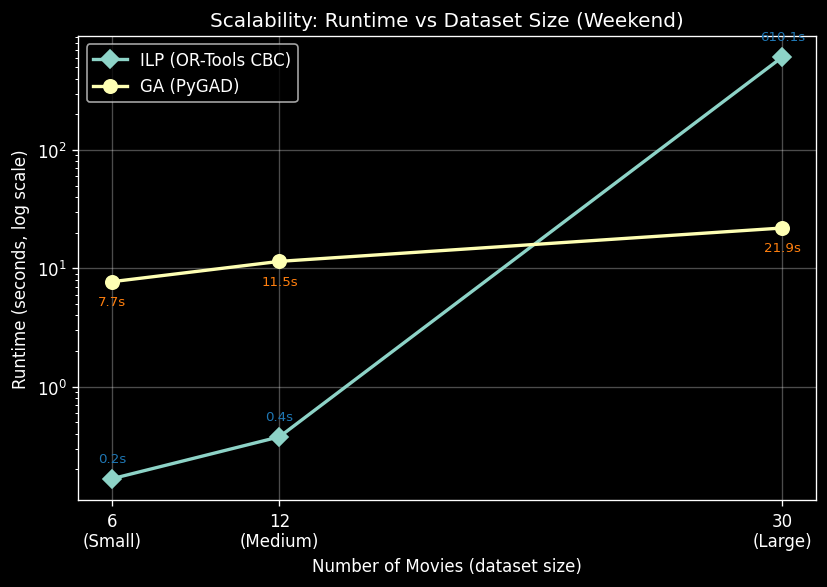

In [29]:
ds_order = ["small", "medium", "large"]
num_movies = [DATASET_NUM_MOVIES[d] for d in ds_order]

ilp_runtimes = [ilp_results[d]["runtime"] for d in ds_order]
ga_runtimes = [ga_comparison_results[d]["runtime"] for d in ds_order]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(num_movies, ilp_runtimes, "D-", markersize=8, linewidth=2, label="ILP (OR-Tools CBC)")
ax.plot(num_movies, ga_runtimes, "o-", markersize=8, linewidth=2, label="GA (PyGAD)")

for x, y_ilp, y_ga in zip(num_movies, ilp_runtimes, ga_runtimes):
    ax.annotate(f"{y_ilp:.1f}s", (x, y_ilp), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="tab:blue")
    ax.annotate(f"{y_ga:.1f}s", (x, y_ga), textcoords="offset points",
                xytext=(0, -14), ha="center", fontsize=8, color="tab:orange")

ax.set_yscale("log")
ax.set_xlabel("Number of Movies (dataset size)")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("Scalability: Runtime vs Dataset Size (Weekend)")
ax.set_xticks(num_movies)
ax.set_xticklabels([f"{n}\n({d.capitalize()})" for n, d in zip(num_movies, ds_order)])
ax.legend()
fig.tight_layout()
plt.show()

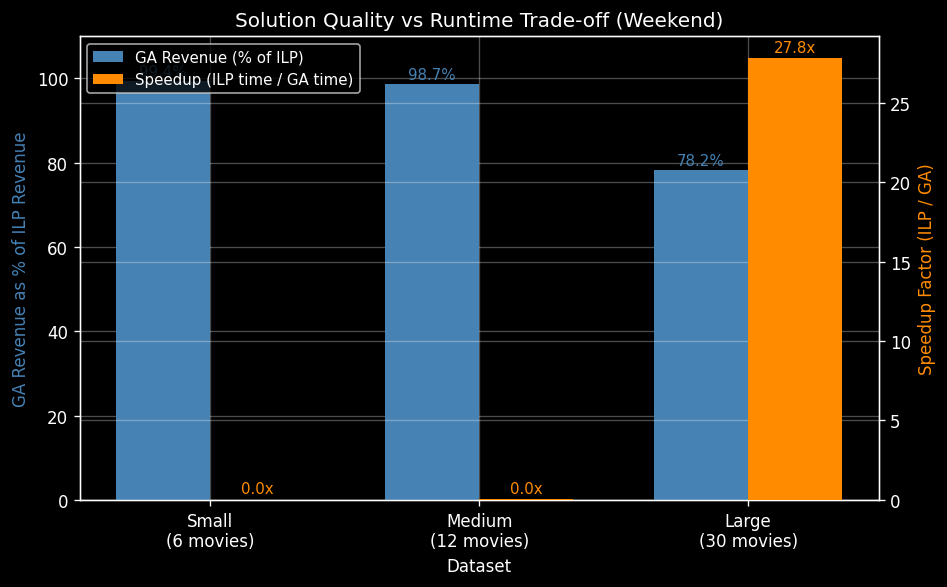

In [30]:
revenue_ratio = []
speedup_factor = []
labels = []

for ds_name in ds_order:
    ilp_rev = ilp_results[ds_name]["revenue"]
    ga_rev = ga_comparison_results[ds_name]["revenue"]
    ilp_t = ilp_results[ds_name]["runtime"]
    ga_t = ga_comparison_results[ds_name]["runtime"]

    ratio = ga_rev / ilp_rev if ilp_rev > 0 else 0.0
    speedup = ilp_t / ga_t if ga_t > 0 else 0.0

    revenue_ratio.append(ratio)
    speedup_factor.append(speedup)
    labels.append(f"{ds_name.capitalize()}\n({DATASET_NUM_MOVIES[ds_name]} movies)")

x = np.arange(len(ds_order))
bar_w = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - bar_w / 2, [r * 100 for r in revenue_ratio], bar_w,
                label="GA Revenue (% of ILP)", color="steelblue", zorder=3)
bars2 = ax2.bar(x + bar_w / 2, speedup_factor, bar_w,
                label="Speedup (ILP time / GA time)", color="darkorange", zorder=3)

for bar, val in zip(bars1, revenue_ratio):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val * 100:.1f}%", ha="center", va="bottom", fontsize=9, color="steelblue")

for bar, val in zip(bars2, speedup_factor):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.1f}x", ha="center", va="bottom", fontsize=9, color="darkorange")

ax1.set_xlabel("Dataset")
ax1.set_ylabel("GA Revenue as % of ILP Revenue", color="steelblue")
ax2.set_ylabel("Speedup Factor (ILP / GA)", color="darkorange")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 110)
ax1.set_title("Solution Quality vs Runtime Trade-off (Weekend)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

In [31]:
print("=" * 72)
print(f"{'Dataset':<10} {'ILP Rev':>12} {'GA Rev':>12} {'GA/ILP':>8} {'ILP Time':>10} {'GA Time':>10} {'Speedup':>8}")
print("-" * 72)
for ds_name in ds_order:
    ilp_rev = ilp_results[ds_name]["revenue"]
    ga_rev = ga_comparison_results[ds_name]["revenue"]
    ratio = ga_rev / ilp_rev if ilp_rev > 0 else 0.0
    ilp_t = ilp_results[ds_name]["runtime"]
    ga_t = ga_comparison_results[ds_name]["runtime"]
    speedup = ilp_t / ga_t if ga_t > 0 else 0.0
    print(f"{ds_name:<10} {ilp_rev:>12,.0f} {ga_rev:>12,.0f} {ratio:>7.1%} {ilp_t:>9.1f}s {ga_t:>9.1f}s {speedup:>7.1f}x")
print("=" * 72)

Dataset         ILP Rev       GA Rev   GA/ILP   ILP Time    GA Time  Speedup
------------------------------------------------------------------------
small             3,884        3,859   99.4%       0.2s       7.7s     0.0x
medium           16,527       16,307   98.7%       0.4s      11.5s     0.0x
large            46,454       36,346   78.2%     610.1s      21.9s    27.8x


## 4. Schedule Gantt Charts

Visual comparison of the final ILP and GA schedules across all datasets. Each chart shows halls on the Y-axis and time on the X-axis, with bars coloured by movie title.

In [32]:
from matplotlib.patches import Patch
import json as _json

def _build_colour_map(schedule: list[dict]) -> dict[str, tuple]:
    """Assign a unique colour to each movie title in the schedule."""
    titles = sorted({row["movie_title"] for row in schedule})
    n = len(titles)
    if n <= 20:
        cmap = plt.cm.tab20
    else:
        cmap = plt.cm.nipy_spectral
    return {title: cmap(i / max(n - 1, 1)) for i, title in enumerate(titles)}


def plot_gantt(
    schedule: list[dict],
    title: str,
    colour_map: dict[str, tuple] | None = None,
    slot_duration: int = 15,
    opening_minutes: int = 600,
) -> None:
    if colour_map is None:
        colour_map = _build_colour_map(schedule)

    hall_ids = sorted({row["hall_id"] for row in schedule}, key=lambda h: (len(h), h))
    hall_y = {h: i for i, h in enumerate(hall_ids)}
    num_halls = len(hall_ids)

    fig_h = max(3.0, num_halls * 0.55 + 1.5)
    fig, ax = plt.subplots(figsize=(14, fig_h))

    max_slot = 0
    for row in schedule:
        h_y = hall_y[row["hall_id"]]
        start = row["start_slot"]
        width = row["end_slot"] - row["start_slot"]
        colour = colour_map.get(row["movie_title"], (0.5, 0.5, 0.5, 1.0))
        ax.barh(h_y, width, left=start, height=0.7, color=colour, edgecolor="white", linewidth=0.5)

        label = row["movie_title"]
        if width >= 4:
            if len(label) > width * 2:
                label = label[:width * 2 - 1] + "."
            ax.text(start + width / 2, h_y, label, ha="center", va="center", fontsize=6, color="black")

        if row["end_slot"] > max_slot:
            max_slot = row["end_slot"]

    ax.set_yticks(range(num_halls))
    ax.set_yticklabels(hall_ids)
    ax.set_ylabel("Hall")
    ax.invert_yaxis()

    tick_every = max(1, 4)
    tick_slots = list(range(0, max_slot + tick_every, tick_every))
    tick_labels = []
    for s in tick_slots:
        total_min = opening_minutes + s * slot_duration
        tick_labels.append(f"{total_min // 60:02d}:{total_min % 60:02d}")
    ax.set_xticks(tick_slots)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)
    ax.set_xlabel("Time")
    ax.set_xlim(-0.5, max_slot + 1)

    ax.set_title(title, fontsize=12)

    handles = [Patch(facecolor=colour_map[t], edgecolor="white", label=t) for t in sorted(colour_map)]
    ncol = max(1, len(handles) // 15 + 1)
    ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=6, ncol=ncol, frameon=False)

    fig.tight_layout()
    plt.show()

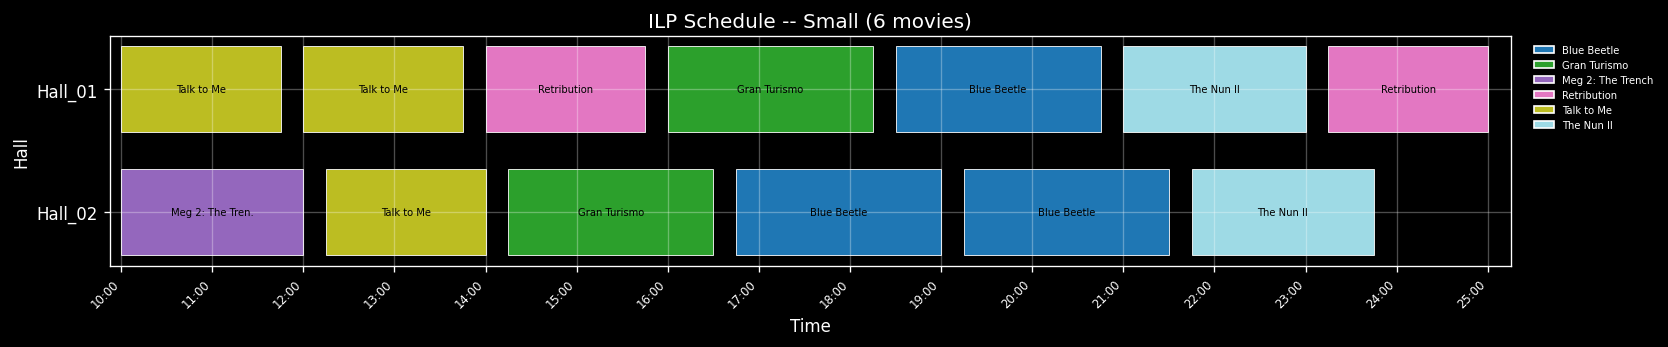

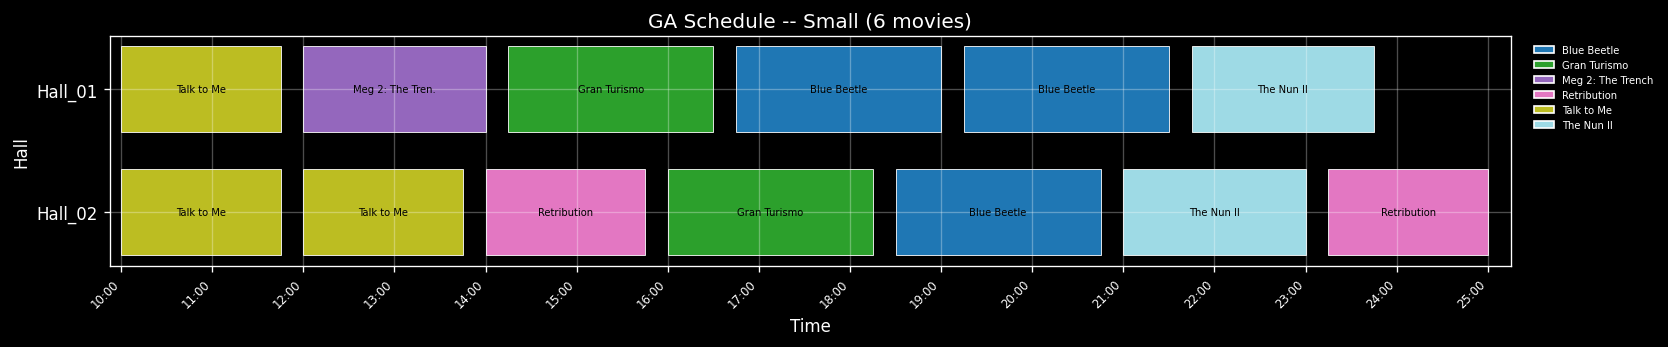

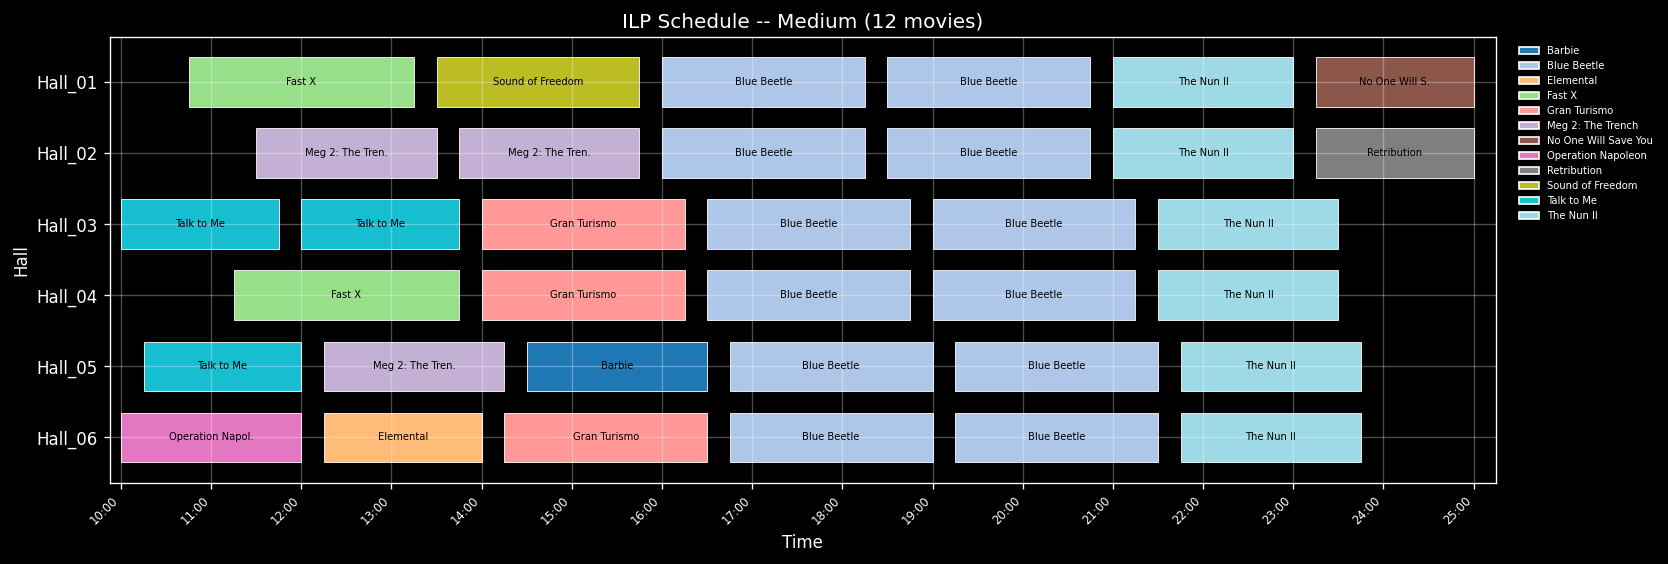

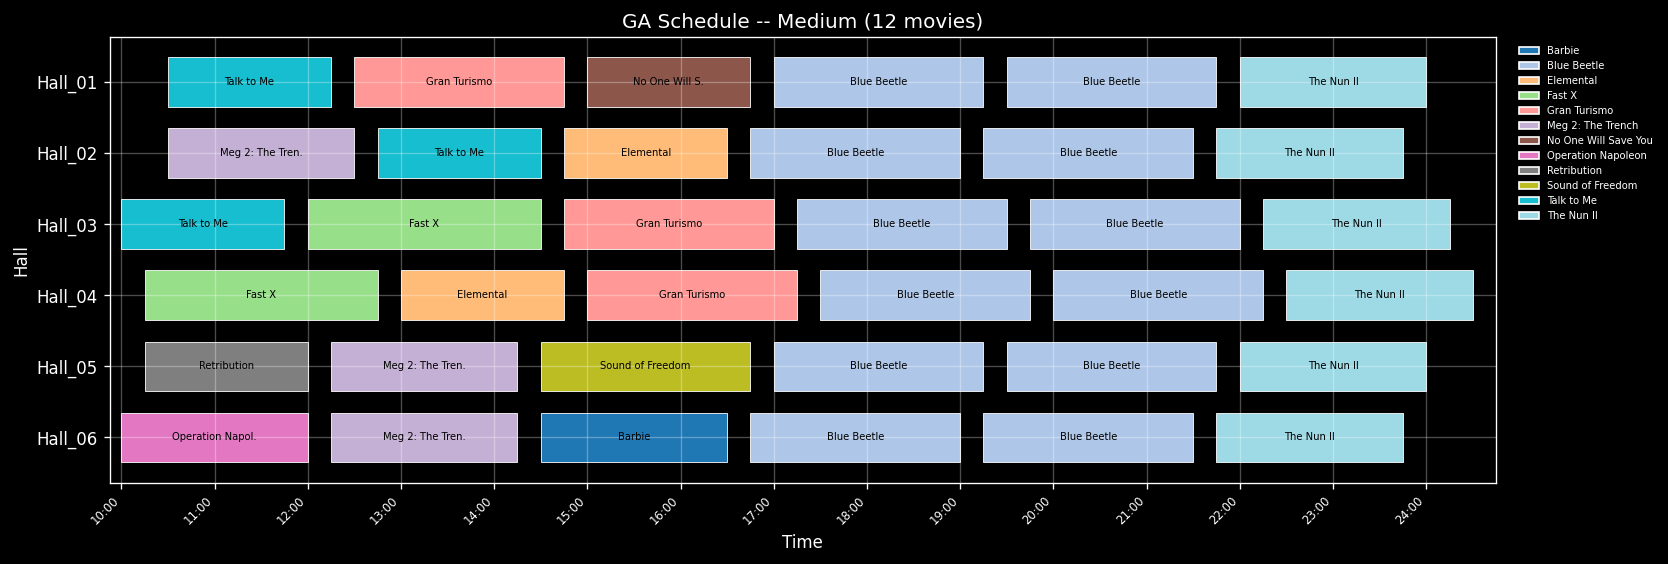

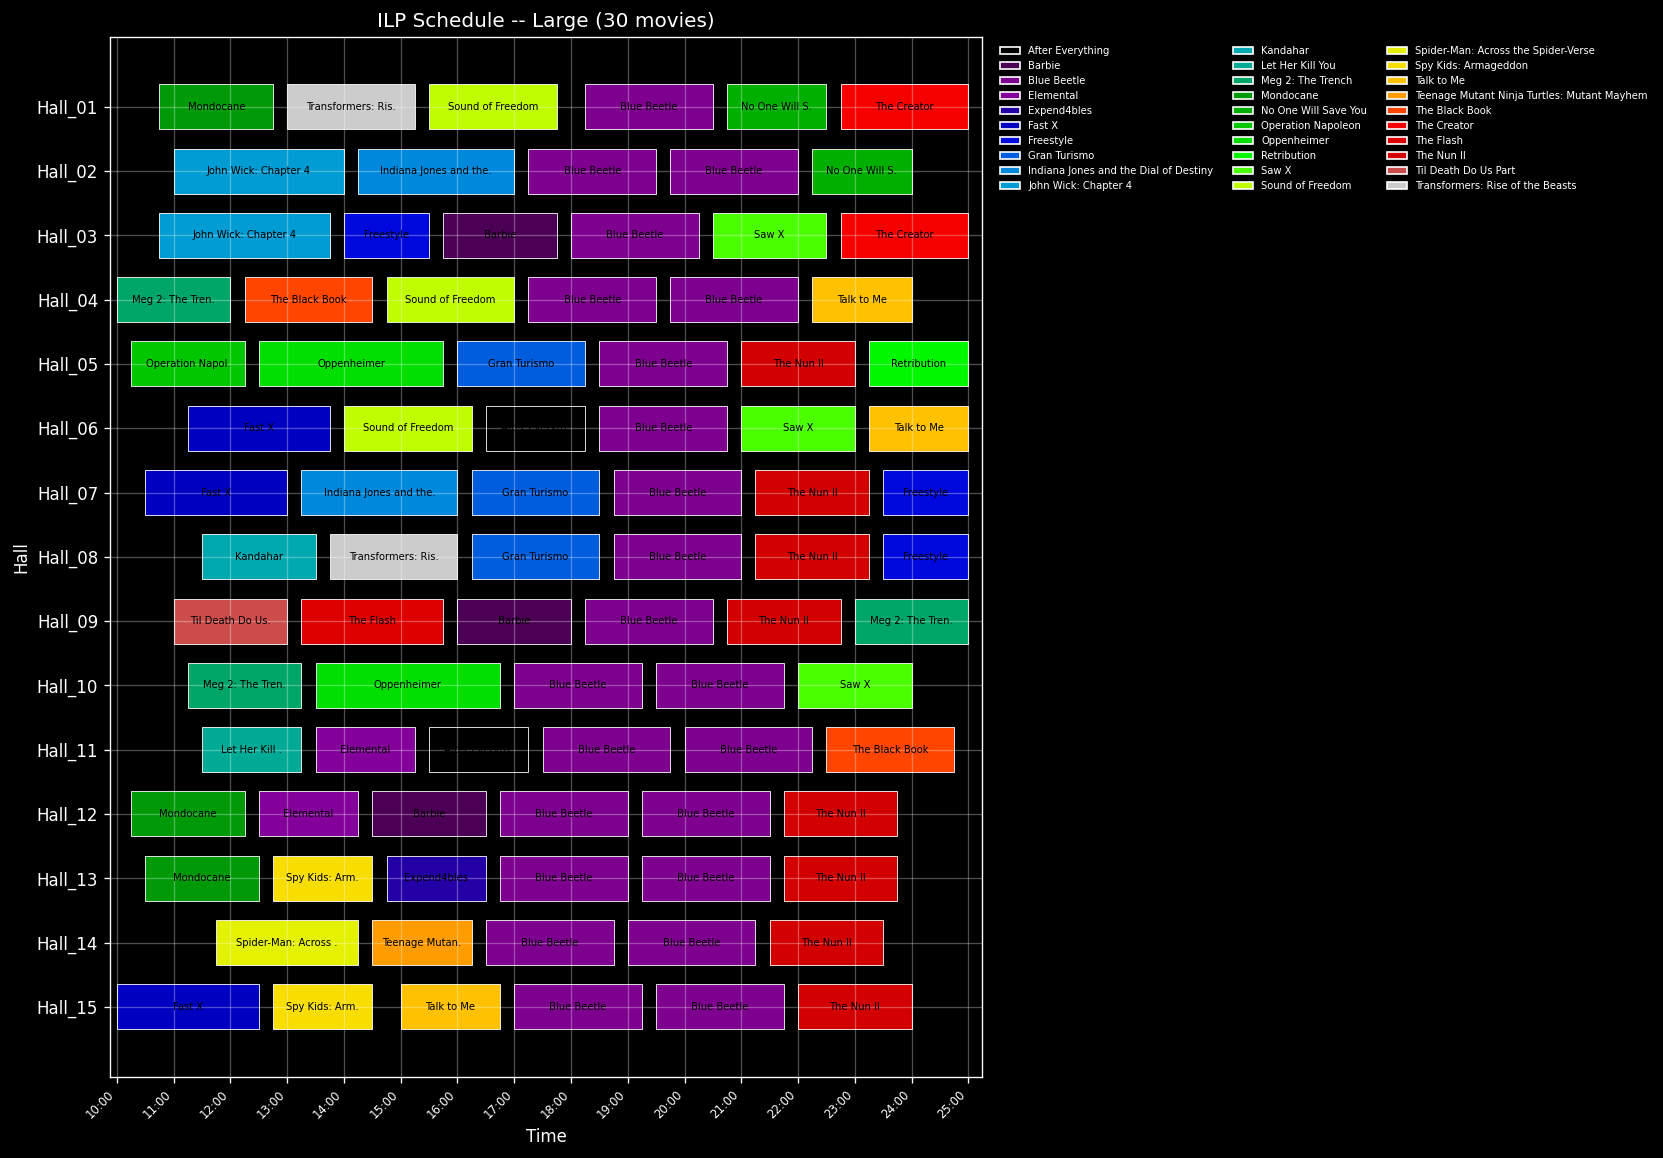

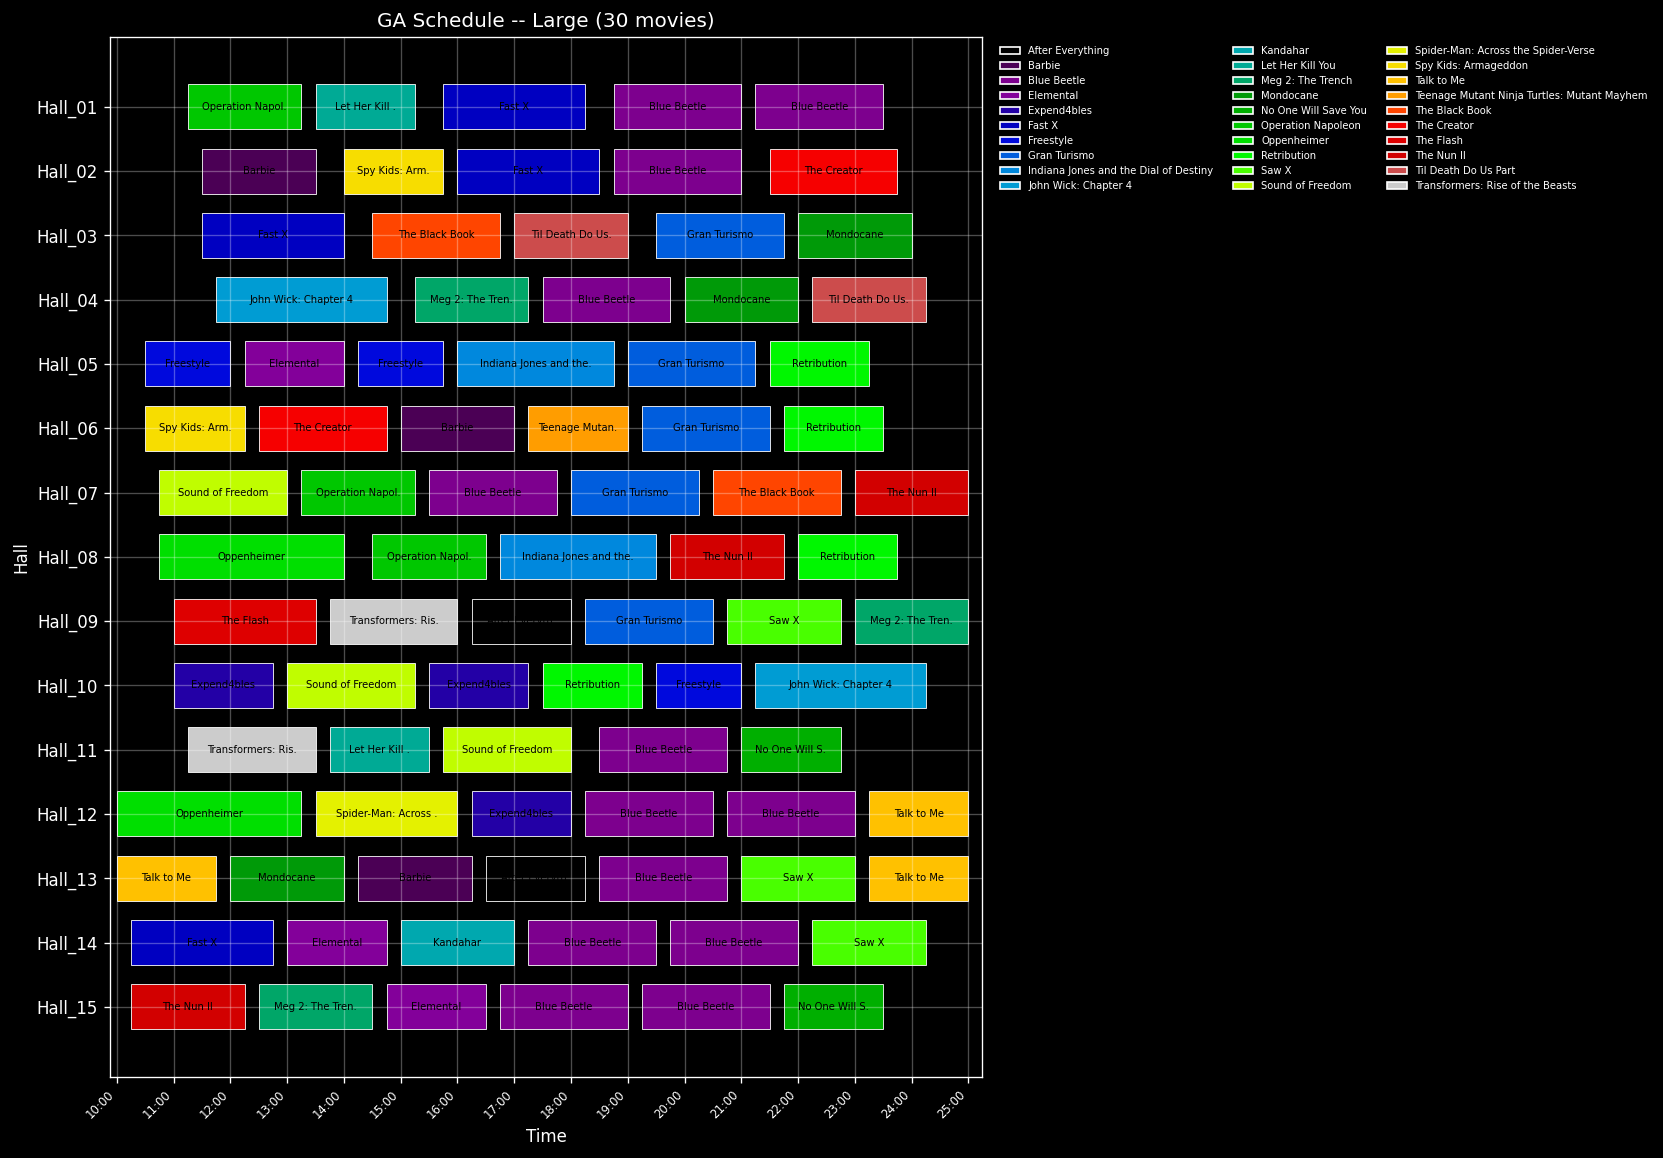

In [33]:
from common.scheduling_config import opening_minutes_from_constraints

_config_cache: dict[str, dict] = {}
for ds_name in ds_order:
    cfg_path = DATASETS[ds_name]["config_json"]
    cfg = _json.loads(cfg_path.read_text(encoding="utf-8"))
    constraints = cfg["constraints"]
    _config_cache[ds_name] = {
        "slot_duration": int(constraints["slot_duration_minutes"]),
        "opening_minutes": opening_minutes_from_constraints(constraints),
    }

for ds_name in ds_order:
    ilp_sched = ilp_results[ds_name]["schedule"]
    ga_sched = ga_comparison_results[ds_name]["schedule"]

    all_titles = {r["movie_title"] for r in ilp_sched} | {r["movie_title"] for r in ga_sched}
    titles_sorted = sorted(all_titles)
    n = len(titles_sorted)
    cmap = plt.cm.tab20 if n <= 20 else plt.cm.nipy_spectral
    shared_colours = {t: cmap(i / max(n - 1, 1)) for i, t in enumerate(titles_sorted)}

    sd = _config_cache[ds_name]["slot_duration"]
    om = _config_cache[ds_name]["opening_minutes"]

    plot_gantt(
        ilp_sched,
        f"ILP Schedule -- {ds_name.capitalize()} ({DATASET_NUM_MOVIES[ds_name]} movies)",
        colour_map=shared_colours,
        slot_duration=sd,
        opening_minutes=om,
    )
    plot_gantt(
        ga_sched,
        f"GA Schedule -- {ds_name.capitalize()} ({DATASET_NUM_MOVIES[ds_name]} movies)",
        colour_map=shared_colours,
        slot_duration=sd,
        opening_minutes=om,
    )

## 5. Summary & Observations

**Fill in after running all cells.**

### Mutation Rate Tuning (Large Dataset)
- Ideal `mutation_percent_genes` = 5%
- Selected as the rate with the highest mean revenue across 5 seeds on the large dataset.

### Generations Tuning (Early Stopping)
- Exploration run: 1000 generations on large dataset.
- Last improvement at generation 984.
- With patience = 50, `OPTIMAL_NUM_GENERATIONS` = 1000.

### Scalability
- ILP runtime grows steeply with dataset size (exponential); GA runtime scales near-linearly.
- On the large dataset, ILP took 613s vs GA 23s (with tuned hyperparameters).

### Quality vs Speed Trade-off
- On small/medium the GA achieves 99.4% / 98.7% of ILP revenue.
- On large the GA achieves 78.2% of ILP revenue while being 26.7x faster.
- Conclusion: the GA provides a practical, scalable alternative when near-optimal solutions are acceptable.

### Schedule Gantt Charts
- Describe visual differences between ILP and GA schedules (e.g. hall utilisation, movie diversity, prime-time allocation).